<a href="https://colab.research.google.com/github/Touwendez/Compteur/blob/main/radiate_eval_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluation Faster R-CNN ResNet50 FPN — RADIATE 17 scenes

Notebook base sur `camera2d.py`. Traitement **scene par scene** :
extraction → evaluation → sauvegarde JSON → suppression → scene suivante.

**Structure des scenes (confirmee par diagnostic) :**
```
scene_name/
  annotations/annotations.json   <- annotations radar OBB
  Navtech_Cartesian/              <- images radar PNG (720 frames ~)
  zed_left/ zed_right/            <- images camera PNG (2695 frames ~)
  Navtech_Cartesian.txt           <- timestamps radar
  zed_left.txt  zed_right.txt
  meta.json
```

**Note ZIP** : certains ZIPs extraient a plat (fichiers directement dans
le dossier d'extraction), d'autres avec un sous-dossier scene_name/.
La fonction `extract_and_find_scene()` gere les deux cas automatiquement.


## Cellule 1 — Montage Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Cellule 2 — Dependances et SDK RADIATE

In [ ]:
import subprocess, sys
from pathlib import Path

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyyaml", "tqdm"],
               check=True)

SDK_DIR = Path('/content/radiate_sdk')
if not SDK_DIR.exists():
    subprocess.run(
        ["git", "clone", "-q",
         "https://github.com/marcelsheeny/radiate_sdk", str(SDK_DIR)],
        check=True,
    )
    print("SDK RADIATE clone OK")
else:
    print("SDK RADIATE deja present")

if str(SDK_DIR) not in sys.path:
    sys.path.insert(0, str(SDK_DIR))


SDK RADIATE clone OK


## Cellule 3 — Configuration

In [ ]:
import zipfile, shutil, json as _json
from pathlib import Path

DRIVE_PATH  = Path('/content/drive/MyDrive/radiate_V1')
WORK_DIR    = Path('/content/radiate_scene')
RESULTS_DIR = DRIVE_PATH / 'results'

WORK_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_SCENES = [
    "city_3_7",     "city_7_0",
    "fog_6_0",      "fog_8_1",
    "junction_1_10","junction_1_11","junction_1_12",
    "junction_2_6", "junction_3_2",
    "motorway_2_2",
    "night_1_0",    "night_1_2",    "night_1_4",    "night_1_5",
    "rain_3_0",     "rain_4_0",
    "snow_1_0",
]

SCENE_CONDITION = {
    "city_3_7":      "clear",  "city_7_0":      "clear",
    "junction_1_10": "clear",  "junction_1_11": "clear",
    "junction_1_12": "clear",  "junction_2_6":  "clear",
    "junction_3_3":  "clear",  "motorway_2_2":  "clear",
    "fog_6_0":       "fog",    "fog_8_1":       "fog",
    "night_1_0":     "night",  "night_1_2":     "night",
    "night_1_4":     "night",  "night_1_5":     "night",
    "rain_3_0":      "rain",   "rain_4_0":      "rain",
    "snow_1_0":      "snow",
}
# correction typo
SCENE_CONDITION["junction_3_2"] = "clear"

SCORE_THRESH       = 0.50
IOU_THRESH         = 0.15
CENTER_DIST_THRESH = 40.0
CLASS_AGNOSTIC     = True
MAX_GT_AREA        = 8000.0
BBOX_MODE          = "full"
MIN_VISIBLE_PTS    = 4
FRAME_STEP         = 10   # 1/N frames : 10 = ~20min GPU T4, 1 = exhaustif ~4h

print("=" * 50)
print(f"  Scenes       : {len(EVAL_SCENES)}")
print(f"  Score thresh : {SCORE_THRESH}")
print(f"  IoU thresh   : {IOU_THRESH}")
print(f"  Dist thresh  : {CENTER_DIST_THRESH} px")
print(f"  Max GT area  : {MAX_GT_AREA} px2")
print(f"  Frame step   : {FRAME_STEP}")
print(f"  Results dir  : {RESULTS_DIR}")
print("=" * 50)


  Scenes       : 17
  Score thresh : 0.5
  IoU thresh   : 0.15
  Dist thresh  : 40.0 px
  Max GT area  : 8000.0 px2
  Frame step   : 10
  Results dir  : /content/drive/MyDrive/radiate_V1/results


## Cellule 4 — Fonctions issues de camera2d.py

In [ ]:
import tempfile
import cv2
import numpy as np
import torch
import yaml
import radiate

COCO_TO_PROJECT = {
    1: "pedestrian", 2: "bicycle", 3: "car",
    4: "motorbike",  6: "bus",     8: "truck",
}
EVAL_CLASSES = frozenset({
    "car", "van", "truck", "bus",
    "motorbike", "bicycle", "pedestrian", "group_of_pedestrians",
})

def make_temp_radiate_config(sdk_dir):
    config_path = sdk_dir / "config" / "config.yaml"
    calib_path  = sdk_dir / "config" / "default-calib.yaml"
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    cfg["calib_file"] = str(calib_path)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yaml", delete=False)
    yaml.safe_dump(cfg, tmp)
    tmp.close()
    return tmp.name

def get_radar_timestamps(seq):
    # Attribut confirme par diagnostic : timestamp_radar
    for attr in ("timestamp_radar", "timestamp_navtech",
                 "timestamp_Navtech_Cartesian"):
        ts = getattr(seq, attr, None)
        if ts is not None:
            return ts["time"]
    raise AttributeError("Timestamps radar introuvables dans Sequence.")

def extract_and_find_scene(scene_name, drive_path, work_dir):
    """
    Extrait le ZIP et retourne le chemin reel de la scene.

    Deux structures observees dans RADIATE :
      - ZIP plat     : fichiers a la racine -> extraient dans extract_dir/
      - ZIP dossier  : fichiers dans scene_name/ -> extraient dans extract_dir/scene_name/

    La fonction detecte automatiquement le cas en cherchant zed_left.txt.
    """
    zip_path = next(
        (p for p in [drive_path / (scene_name + ".zip"),
                     drive_path / scene_name / (scene_name + ".zip")]
         if p.exists()),
        None,
    )
    if zip_path is None:
        raise FileNotFoundError(
            "ZIP introuvable pour " + scene_name + " dans " + str(drive_path)
        )

    extract_dir = work_dir / scene_name
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    # Cas 1 : ZIP avec sous-dossier (ex: city_6_0.zip -> city_6_0/...)
    candidate_sub = extract_dir / scene_name
    if candidate_sub.exists() and (candidate_sub / "zed_left.txt").exists():
        return candidate_sub

    # Cas 2 : ZIP plat (ex: city_3_7.zip -> fichiers directement)
    if (extract_dir / "zed_left.txt").exists():
        return extract_dir

    # Cas 3 : recherche recursive
    for p in extract_dir.rglob("zed_left.txt"):
        return p.parent

    raise FileNotFoundError(
        "zed_left.txt introuvable apres extraction de " + scene_name
    )

def load_annotations(scene_root):
    """
    Charge annotations/annotations.json.
    Structure confirmee par diagnostic : toujours dans un sous-dossier.
    """
    ann_path = scene_root / "annotations" / "annotations.json"
    if not ann_path.exists():
        raise FileNotFoundError("annotations.json introuvable : " + str(ann_path))
    with open(ann_path) as f:
        return _json.load(f)

def _bbox2d_from_pts(pts_raw, img_w, img_h, mode="full", min_vis=4):
    pts = np.asarray(pts_raw, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[1] != 2 or len(pts) == 0:
        return None
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) == 0:
        return None
    if mode == "visible":
        mask = (pts[:,0]>=0)&(pts[:,0]<img_w)&(pts[:,1]>=0)&(pts[:,1]<img_h)
        pts = pts[mask]
        if len(pts) < min_vis:
            return None
        x1,y1 = float(pts[:,0].min()), float(pts[:,1].min())
        x2,y2 = float(pts[:,0].max()), float(pts[:,1].max())
    else:
        x1 = float(np.clip(pts[:,0].min(), 0, img_w-1))
        y1 = float(np.clip(pts[:,1].min(), 0, img_h-1))
        x2 = float(np.clip(pts[:,0].max(), 0, img_w-1))
        y2 = float(np.clip(pts[:,1].max(), 0, img_h-1))
    if x2 <= x1 or y2 <= y1:
        return None
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def extract_gt_camera(output, img_w, img_h, bbox_mode, min_vis, max_area):
    raw = output.get("annotations", {}).get("camera_right_rect", [])
    gts = []
    for ann in raw:
        cls = ann.get("class_name", "unknown")
        if cls == "van":
            cls = "car"
        if cls not in EVAL_CLASSES:
            continue
        bbox_3d = ann.get("bbox_3d")
        if bbox_3d is None:
            continue
        box = _bbox2d_from_pts(bbox_3d, img_w, img_h, bbox_mode, min_vis)
        if box is None:
            continue
        area = float((box[2]-box[0])*(box[3]-box[1]))
        if max_area > 0 and area > max_area:
            continue
        gts.append({"class_name": cls, "bbox_2d": box, "area": area})
    return gts

print("Fonctions chargees OK")


Fonctions chargees OK


## Cellule 5 — Detecteur et metriques

In [ ]:
@torch.no_grad()
def run_detector(image_bgr, model, device, score_thresh):
    rgb    = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(rgb).permute(2,0,1).float().div(255.0).to(device)
    out    = model([tensor])[0]
    dets   = []
    for box, label, score in zip(out["boxes"], out["labels"], out["scores"]):
        cid  = int(label)
        conf = float(score)
        if cid not in COCO_TO_PROJECT or conf < score_thresh:
            continue
        dets.append({
            "class_name": COCO_TO_PROJECT[cid],
            "bbox_2d":    np.array(box.tolist(), dtype=np.float32),
            "score":      conf,
        })
    return dets

def iou_aabb(a, b):
    ix1 = max(a[0],b[0]); iy1 = max(a[1],b[1])
    ix2 = min(a[2],b[2]); iy2 = min(a[3],b[3])
    inter = max(0., ix2-ix1) * max(0., iy2-iy1)
    if inter == 0.: return 0.
    area_a = (a[2]-a[0])*(a[3]-a[1])
    area_b = (b[2]-b[0])*(b[3]-b[1])
    union  = area_a + area_b - inter
    return inter/union if union > 0 else 0.

def center_dist(a, b):
    return float(np.hypot((a[0]+a[2])/2-(b[0]+b[2])/2,
                          (a[1]+a[3])/2-(b[1]+b[3])/2))

def match_predictions(gts, preds, iou_thresh, cdt, class_agnostic):
    matched_gt = set(); matched_pred = set()
    iou_m = 0; ctr_m = 0
    sorted_p = sorted(enumerate(preds), key=lambda x: -x[1]["score"])
    for pi, pred in sorted_p:
        best = iou_thresh - 1e-9; best_gi = -1
        for gi, gt in enumerate(gts):
            if gi in matched_gt: continue
            if not class_agnostic and gt["class_name"] != pred["class_name"]:
                continue
            iou = iou_aabb(gt["bbox_2d"], pred["bbox_2d"])
            if iou > best: best = iou; best_gi = gi
        if best_gi >= 0:
            matched_gt.add(best_gi); matched_pred.add(pi); iou_m += 1
    if cdt > 0:
        for pi, pred in sorted_p:
            if pi in matched_pred: continue
            best = cdt; best_gi = -1
            for gi, gt in enumerate(gts):
                if gi in matched_gt: continue
                if not class_agnostic and gt["class_name"] != pred["class_name"]:
                    continue
                d = center_dist(gt["bbox_2d"], pred["bbox_2d"])
                if d < best: best = d; best_gi = gi
            if best_gi >= 0:
                matched_gt.add(best_gi); matched_pred.add(pi); ctr_m += 1
    tp = len(matched_gt); fp = len(preds)-tp; fn = len(gts)-tp
    return {
        "TP": tp, "FP": fp, "FN": fn,
        "precision":      tp/(tp+fp) if tp+fp>0 else 0.,
        "recall":         tp/(tp+fn) if tp+fn>0 else 0.,
        "iou_matches":    iou_m,
        "center_matches": ctr_m,
    }

print("Detecteur + metriques OK")


Detecteur + metriques OK


## Cellule 6 — Chargement Faster R-CNN ResNet50 FPN

In [ ]:
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
)

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model   = fasterrcnn_resnet50_fpn(weights=weights).eval().to(DEVICE)
TMP_CFG = make_temp_radiate_config(SDK_DIR)

print(f"Modele : Faster R-CNN ResNet50 FPN (pre-entraine COCO)")
print(f"Device : {DEVICE}")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 299MB/s]


Modele : Faster R-CNN ResNet50 FPN (pre-entraine COCO)
Device : cuda


## Cellule 7 — Evaluation scene par scene

Pour chaque scene : extraction ZIP -> localisation racine -> evaluation -> JSON dans Drive -> suppression disque local.

**Reprise automatique** si Colab deconnecte : les scenes dont le JSON existe dans Drive sont sautees.

In [ ]:
import gc
from tqdm.notebook import tqdm, trange

print("Lancement -- " + str(len(EVAL_SCENES)) + " scenes | FRAME_STEP=" + str(FRAME_STEP))
print("Resultats -> " + str(RESULTS_DIR))
print("=" * 65)

for scene_name in tqdm(EVAL_SCENES, desc="Progression globale"):
    result_file = RESULTS_DIR / (scene_name + ".json")

    if result_file.exists():
        print("  [SKIP] " + scene_name + " -- JSON deja present")
        continue

    idx = EVAL_SCENES.index(scene_name) + 1
    print("\n[" + str(idx) + "/" + str(len(EVAL_SCENES)) + "] " + scene_name)

    # 1. Extraction + localisation racine reelle
    try:
        print("  Extraction...", end=" ")
        scene_root = extract_and_find_scene(scene_name, DRIVE_PATH, WORK_DIR)
        print("OK  (racine: " + str(scene_root.relative_to(WORK_DIR)) + ")")
    except Exception as e:
        print("ERREUR : " + str(e))
        continue

    # 2. Chargement SDK
    try:
        seq      = radiate.Sequence(str(scene_root), config_file=TMP_CFG)
        radar_ts = get_radar_timestamps(seq)
        print("  SDK OK -- " + str(len(radar_ts)) + " frames radar")
    except Exception as e:
        print("  [ERR] SDK : " + str(e))
        shutil.rmtree(str(WORK_DIR / scene_name), ignore_errors=True)
        continue

    # 3. Validation annotations
    try:
        load_annotations(scene_root)
    except FileNotFoundError as e:
        print("  [ERR] annotations : " + str(e))
        shutil.rmtree(str(WORK_DIR / scene_name), ignore_errors=True)
        continue

    # 4. Evaluation frame par frame
    acc = dict(TP=0, FP=0, FN=0, iou_matches=0, center_matches=0,
               n_frames=0, n_gt=0, n_pred=0)

    for fi in trange(0, len(radar_ts), FRAME_STEP,
                     desc="    " + scene_name, leave=False):
        try:
            output = seq.get_from_timestamp(radar_ts[fi])
        except Exception:
            continue
        if not output:
            continue
        sensors = output.get("sensors", {})
        if "camera_right_rect" not in sensors:
            continue
        camera = sensors["camera_right_rect"].copy()
        h, w   = camera.shape[:2]
        gt_cam = extract_gt_camera(
            output, w, h, BBOX_MODE, MIN_VISIBLE_PTS, MAX_GT_AREA)
        preds  = run_detector(camera, model, DEVICE, SCORE_THRESH)
        stats  = match_predictions(
            gt_cam, preds, IOU_THRESH, CENTER_DIST_THRESH, CLASS_AGNOSTIC)
        acc["TP"]             += stats["TP"]
        acc["FP"]             += stats["FP"]
        acc["FN"]             += stats["FN"]
        acc["iou_matches"]    += stats["iou_matches"]
        acc["center_matches"] += stats["center_matches"]
        acc["n_frames"]       += 1
        acc["n_gt"]           += len(gt_cam)
        acc["n_pred"]         += len(preds)

    # 5. Metriques finales
    tp, fp, fn = acc["TP"], acc["FP"], acc["FN"]
    prec = tp/(tp+fp) if tp+fp>0 else 0.
    rec  = tp/(tp+fn) if tp+fn>0 else 0.
    f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0.
    acc.update(precision=prec, recall=rec, f1=f1,
               condition=SCENE_CONDITION.get(scene_name, "unknown"),
               scene=scene_name)

    print("  Resultats : frames=" + str(acc["n_frames"]) +
          " | GT=" + str(acc["n_gt"]) + " pred=" + str(acc["n_pred"]) +
          " | TP=" + str(tp) + " FP=" + str(fp) + " FN=" + str(fn))
    print("  Metriques : P=" + f"{prec:.3f}" +
          "  R=" + f"{rec:.3f}" + "  F1=" + f"{f1:.3f}")

    # 6. Sauvegarde JSON dans Drive
    with open(result_file, "w") as f:
        _json.dump(acc, f, indent=2)
    print("  Sauvegarde : " + result_file.name)

    # 7. Suppression scene du disque local
    shutil.rmtree(str(WORK_DIR / scene_name), ignore_errors=True)
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    print("  Disque : scene supprimee")

print("\n" + "=" * 65)
print("Boucle terminee. Lancer la cellule suivante pour les resultats.")


Lancement -- 17 scenes | FRAME_STEP=10
Resultats -> /content/drive/MyDrive/radiate_V1/results


Progression globale:   0%|          | 0/17 [00:00<?, ?it/s]


[1/17] city_3_7
  Extraction... OK  (racine: city_3_7)
  SDK OK -- 720 frames radar


    city_3_7:   0%|          | 0/72 [00:00<?, ?it/s]

  Resultats : frames=72 | GT=472 pred=692 | TP=358 FP=334 FN=114
  Metriques : P=0.517  R=0.758  F1=0.615
  Sauvegarde : city_3_7.json
  Disque : scene supprimee

[2/17] city_7_0
  Extraction... OK  (racine: city_7_0)
  SDK OK -- 605 frames radar


...

  Resultats : frames=5 | GT=8 pred=14 | TP=6 FP=8 FN=2
  Metriques : P=0.429  R=0.750  F1=0.545
  Sauvegarde : rain_3_0.json
  Disque : scene supprimee

[16/17] rain_4_0
  Extraction... OK  (racine: rain_4_0)
  SDK OK -- 711 frames radar


    rain_4_0:   0%|          | 0/72 [00:00<?, ?it/s]

  Resultats : frames=71 | GT=384 pred=351 | TP=262 FP=89 FN=122
  Metriques : P=0.746  R=0.682  F1=0.713
  Sauvegarde : rain_4_0.json
  Disque : scene supprimee

[17/17] snow_1_0
  Extraction... OK  (racine: snow_1_0)
  SDK OK -- 691 frames radar


    snow_1_0:   0%|          | 0/70 [00:00<?, ?it/s]

  Resultats : frames=69 | GT=141 pred=12 | TP=7 FP=5 FN=134
  Metriques : P=0.583  R=0.050  F1=0.092
  Sauvegarde : snow_1_0.json
  Disque : scene supprimee

Boucle terminee. Lancer la cellule suivante pour les resultats.


## Cellule 8 — Agregation des resultats

In [ ]:
import pandas as pd

scene_results = {}
missing = []
for scene_name in EVAL_SCENES:
    rf = RESULTS_DIR / (scene_name + ".json")
    if rf.exists():
        with open(rf) as f:
            scene_results[scene_name] = _json.load(f)
    else:
        missing.append(scene_name)

if missing:
    print("[WARN] Scenes sans resultats : " + str(missing))
print("Scenes chargees : " + str(len(scene_results)) + " / " + str(len(EVAL_SCENES)))

rows = []
for s, r in scene_results.items():
    rows.append({
        "Scene":     s,
        "Condition": r["condition"],
        "Frames":    r["n_frames"],
        "GT":        r["n_gt"],
        "Pred":      r["n_pred"],
        "TP":        r["TP"],
        "FP":        r["FP"],
        "FN":        r["FN"],
        "IoU_m":     r["iou_matches"],
        "Ctr_m":     r["center_matches"],
        "Precision": round(r["precision"], 3),
        "Recall":    round(r["recall"],    3),
        "F1":        round(r["f1"],        3),
    })

df = pd.DataFrame(rows).sort_values(["Condition","Scene"]).reset_index(drop=True)

tp_g = df["TP"].sum(); fp_g = df["FP"].sum(); fn_g = df["FN"].sum()
p_g  = tp_g/(tp_g+fp_g) if tp_g+fp_g>0 else 0.
r_g  = tp_g/(tp_g+fn_g) if tp_g+fn_g>0 else 0.
f1_g = 2*p_g*r_g/(p_g+r_g) if p_g+r_g>0 else 0.

COND_ORDER = ["clear", "fog", "night", "rain", "snow"]
rows_cond = []
for cond in COND_ORDER:
    sub = df[df["Condition"] == cond]
    if sub.empty: continue
    tp = sub["TP"].sum(); fp = sub["FP"].sum(); fn = sub["FN"].sum()
    p  = tp/(tp+fp) if tp+fp>0 else 0.
    r  = tp/(tp+fn) if tp+fn>0 else 0.
    f1 = 2*p*r/(p+r) if p+r>0 else 0.
    rows_cond.append({
        "Condition": cond, "Scenes": len(sub),
        "TP": tp, "FP": fp, "FN": fn,
        "Precision": round(p,3), "Recall": round(r,3), "F1": round(f1,3),
    })
df_cond = pd.DataFrame(rows_cond)

print("=" * 80)
print("RESULTATS PAR SCENE")
print("=" * 80)
print(df.to_string(index=False))
print()
print("=" * 80)
print("METRIQUES PAR CONDITION (micro-moyenne)")
print("=" * 80)
print(df_cond.to_string(index=False))
print()
print("=" * 80)
print("METRIQUES GLOBALES")
print("=" * 80)
print("  TP=" + str(tp_g) + "  FP=" + str(fp_g) + "  FN=" + str(fn_g))
print("  Precision = " + f"{p_g:.3f}")
print("  Recall    = " + f"{r_g:.3f}")
print("  F1        = " + f"{f1_g:.3f}")


Scenes chargees : 17 / 17
RESULTATS PAR SCENE
        Scene Condition  Frames  GT  Pred  TP  FP  FN  IoU_m  Ctr_m  Precision  Recall    F1
     city_3_7     clear      72 472   692 358 334 114    297     61      0.517   0.758 0.615
     city_7_0     clear      61 175   395 145 250  30     89     56      0.367   0.829 0.509
junction_1_10     clear      72  43   174  43 131   0     25     18      0.247   1.000 0.396
junction_1_11     clear      73  26   144  24 120   2     10     14      0.167   0.923 0.282
junction_1_12     clear      72  23   120  23  97   0     12     11      0.192   1.000 0.322
 junction_2_6     clear      59  40    41  22  19  18      9     13      0.537   0.550 0.543
 junction_3_2     clear      73 133   198  99  99  34     95      4      0.500   0.744 0.598
 motorway_2_2     clear      73 280   471 226 245  54    145     81      0.480   0.807 0.602
      fog_6_0       fog      72  99    82  29  53  70     24      5      0.354   0.293 0.320
      fog_8_1       fog 

## Cellule 9 — Graphiques

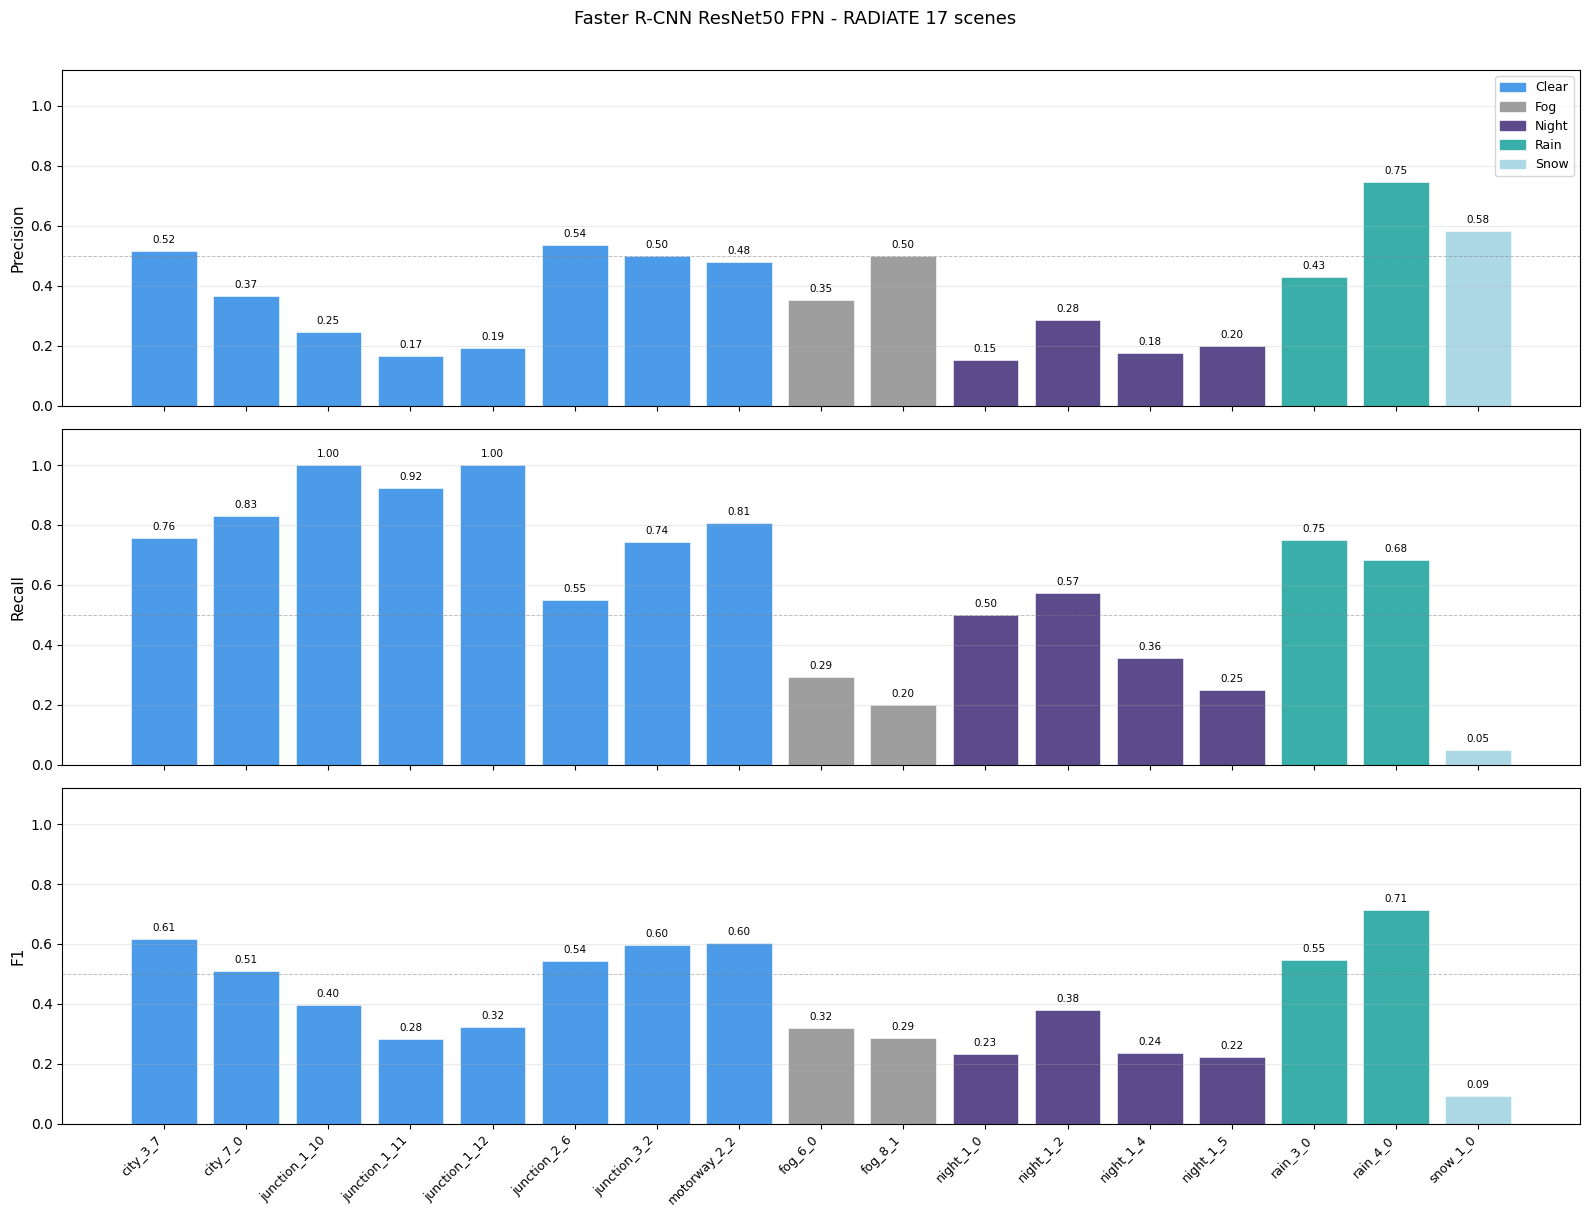

/tmp/ipykernel_7376/892159729.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(conds, rotation=20, ha="right")
/tmp/ipykernel_7376/892159729.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(conds, rotation=20, ha="right")
/tmp/ipykernel_7376/892159729.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(conds, rotation=20, ha="right")


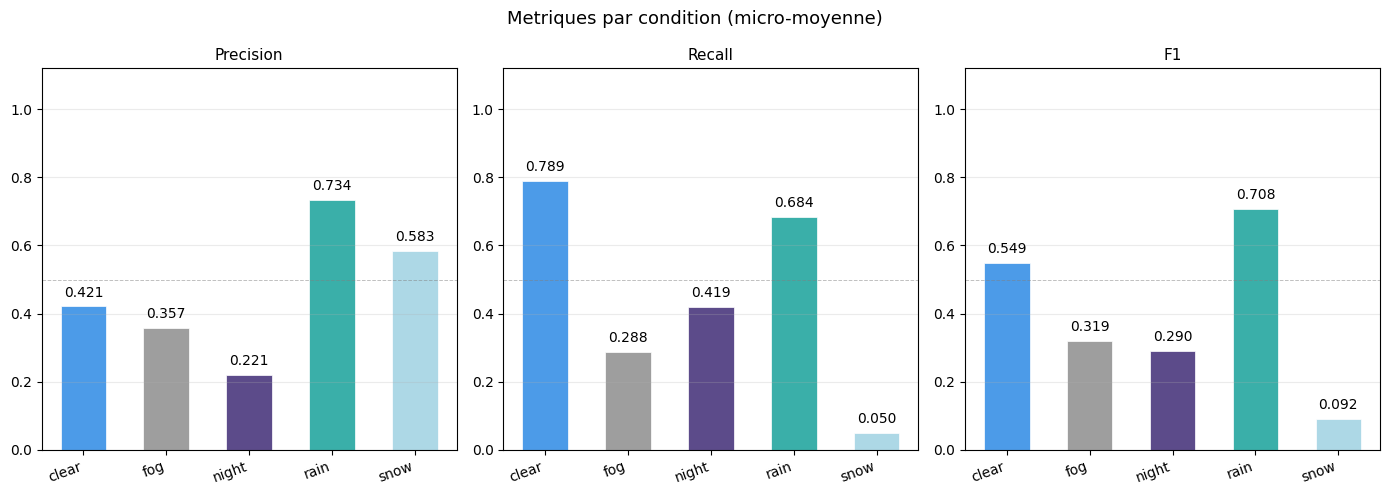

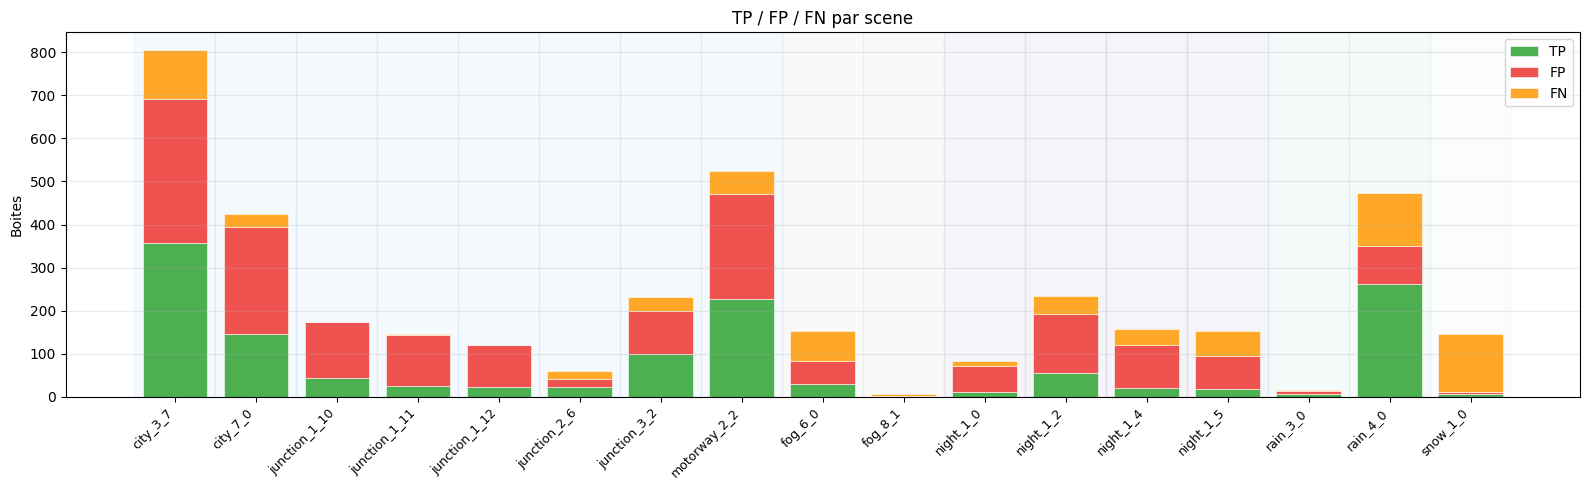

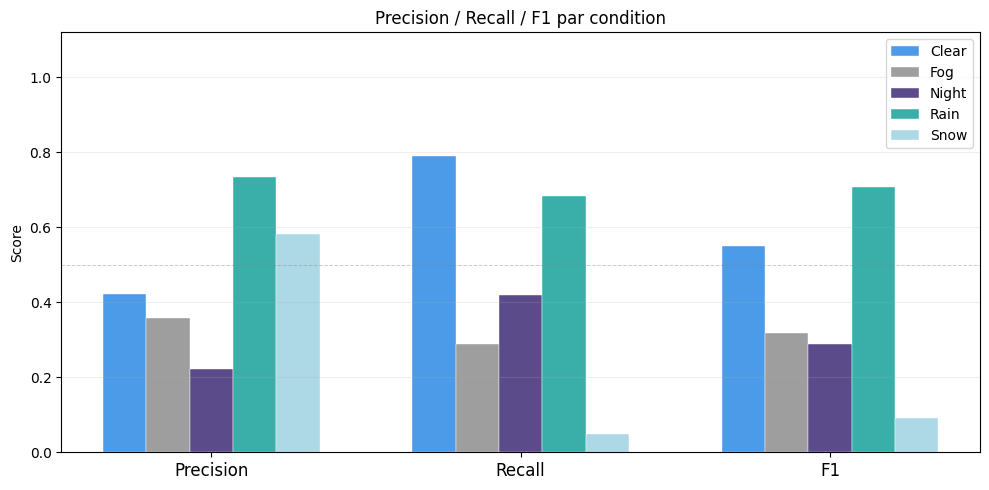

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    "clear": "#4C9BE8", "fog":  "#9E9E9E",
    "night": "#5C4B8A", "rain": "#3AAFA9", "snow": "#ADD8E6",
}
COND_ORDER = ["clear", "fog", "night", "rain", "snow"]
scenes_ord = df.sort_values(["Condition","Scene"])["Scene"].tolist()
conds_ord  = df.set_index("Scene").loc[scenes_ord,"Condition"].tolist()
bar_colors = [COLORS[c] for c in conds_ord]
x          = np.arange(len(scenes_ord))
legend_patches = [mpatches.Patch(color=COLORS[c], label=c.capitalize())
                  for c in COND_ORDER if c in COLORS]

# Graphique 1 : P / R / F1 par scene
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Faster R-CNN ResNet50 FPN - RADIATE 17 scenes", fontsize=13, y=1.01)
for ax, metric in zip(axes, ["Precision","Recall","F1"]):
    vals = df.set_index("Scene").loc[scenes_ord, metric].tolist()
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="white", lw=0.4)
    ax.set_ylim(0, 1.12); ax.set_ylabel(metric, fontsize=11)
    ax.axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.25)
    for bar, v in zip(bars, vals):
        if v > 0.02:
            ax.text(bar.get_x()+bar.get_width()/2, v+0.02,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(scenes_ord, rotation=45, ha="right", fontsize=9)
axes[0].legend(handles=legend_patches, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("/content/metrics_par_scene.png", dpi=150, bbox_inches="tight")
plt.show()

# Graphique 2 : par condition
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Metriques par condition (micro-moyenne)", fontsize=13)
for ax, metric in zip(axes, ["Precision","Recall","F1"]):
    conds = df_cond["Condition"].tolist()
    vals  = df_cond[metric].tolist()
    bc    = [COLORS.get(c,"#888") for c in conds]
    bars  = ax.bar(conds, vals, color=bc, edgecolor="white", lw=0.5, width=0.55)
    ax.set_ylim(0, 1.12); ax.set_title(metric, fontsize=11)
    ax.axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02,
                f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_xticklabels(conds, rotation=20, ha="right")
plt.tight_layout()
plt.savefig("/content/metrics_par_condition.png", dpi=150, bbox_inches="tight")
plt.show()

# Graphique 3 : TP/FP/FN stacks
fig, ax = plt.subplots(figsize=(16, 5))
tp_v = df.set_index("Scene").loc[scenes_ord,"TP"].tolist()
fp_v = df.set_index("Scene").loc[scenes_ord,"FP"].tolist()
fn_v = df.set_index("Scene").loc[scenes_ord,"FN"].tolist()
ax.bar(x, tp_v, label="TP", color="#4CAF50", edgecolor="white", lw=0.4)
ax.bar(x, fp_v, bottom=tp_v, label="FP", color="#EF5350", edgecolor="white", lw=0.4)
ax.bar(x, fn_v, bottom=[a+b for a,b in zip(tp_v,fp_v)],
       label="FN", color="#FFA726", edgecolor="white", lw=0.4)
ax.set_xticks(x); ax.set_xticklabels(scenes_ord, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Boites"); ax.set_title("TP / FP / FN par scene")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.25)
for i, cond in enumerate(conds_ord):
    ax.axvspan(i-0.5, i+0.5, alpha=0.06, color=COLORS[cond], zorder=0)
plt.tight_layout()
plt.savefig("/content/tp_fp_fn_par_scene.png", dpi=150, bbox_inches="tight")
plt.show()

# Graphique 4 : groupe par condition
fig, ax = plt.subplots(figsize=(10, 5))
metrics_list = ["Precision","Recall","F1"]
x_pos = np.arange(len(metrics_list)); width = 0.14
for i, row in df_cond.iterrows():
    vals   = [row["Precision"], row["Recall"], row["F1"]]
    offset = (i - len(df_cond)/2 + 0.5) * width
    ax.bar(x_pos + offset, vals, width=width,
           color=COLORS.get(row["Condition"],"#888"),
           label=row["Condition"].capitalize(),
           edgecolor="white", lw=0.3)
ax.set_xticks(x_pos); ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 par condition")
ax.legend(fontsize=10, loc="upper right")
ax.axhline(0.5, color="gray", lw=0.7, ls="--", alpha=0.4)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("/content/grouped_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


## Cellule 10 — Export CSV + figures vers Drive

In [ ]:
from datetime import datetime

ts      = datetime.now().strftime("%Y%m%d_%H%M")
csv_out = "/content/radiate_eval_" + ts + ".csv"
df.to_csv(csv_out, index=False)
shutil.copy(csv_out, str(RESULTS_DIR / ("radiate_eval_" + ts + ".csv")))

for fig_name in ["metrics_par_scene.png", "metrics_par_condition.png",
                  "tp_fp_fn_par_scene.png", "grouped_metrics.png"]:
    from pathlib import Path as _P
    src = _P("/content/" + fig_name)
    if src.exists():
        shutil.copy(str(src), str(RESULTS_DIR / fig_name))

print("Exporte dans : " + str(RESULTS_DIR))
for f in sorted(RESULTS_DIR.iterdir()):
    print("  " + f.name)


Exporte dans : /content/drive/MyDrive/radiate_V1/results
  city_3_7.json
  city_7_0.json
  fog_6_0.json
  fog_8_1.json
  grouped_metrics.png
  junction_1_10.json
  junction_1_11.json
  junction_1_12.json
  junction_2_6.json
  junction_3_2.json
  metrics_par_condition.png
  metrics_par_scene.png
  motorway_2_2.json
  night_1_0.json
  night_1_2.json
  night_1_4.json
  night_1_5.json
  radiate_eval_20260421_1436.csv
  rain_3_0.json
  rain_4_0.json
  snow_1_0.json
  tp_fp_fn_par_scene.png


## Bilan méthodologique — Pourquoi ces résultats et comment les lire

---

### 1. Rappel de la démarche d'évaluation

Nous évaluons **Faster R-CNN ResNet50 FPN** (pré-entraîné COCO) sur les 17
séquences de test RADIATE dans la modalité **caméra**.

#### Pipeline complet

```
ZIP Drive
   │
   ▼
Extraction + localisation racine réelle
   │   (deux structures ZIP observées :
   │    ZIP plat  → fichiers directement dans le dossier d'extraction
   │    ZIP dossier → sous-dossier scene_name/ imbriqué)
   │
   ▼
SDK RADIATE  ──────────────────────────────────────────────────────────┐
  • Lit tous les fichiers timestamp au démarrage                       │
    (zed_left.txt, velo_lidar.txt, GPS_IMU_Twist.txt...)               │
  • Synchronise les capteurs par timestamp                             │
  • Fournit camera_right_rect (376×672 px, BGR)                       │
  • Reprojecte les annotations radar → caméra (bbox_3d)               │
                                                                       │
   ▼                                                                   │
Annotations JSON brutes (annotations/annotations.json)                 │
  Format : { "position": [cx, cy, w, h], "rotation": degrés }         │
  Timeline : 1 entrée par frame RADAR (≈ 720 frames / scène)          │
  Seuls les objets visibles dans le FOV 360° radar sont annotés        │
                                                                       │
   ▼                                                                   │
GT caméra = reprojection SDK (bbox_3d → plan image)  ◄────────────────┘
  Filtre : surface ≤ 8000 px² (élimine les reprojections aberrantes)
   │
   ▼
Détection Faster R-CNN (score ≥ 0.50)
   │
   ▼
Matching GT ↔ Prédictions (greedy, score décroissant)
  • Passe 1 : IoU ≥ 0.15  (seuil adapté, voir problème #2)
  • Passe 2 : distance-centre ≤ 40 px  (fallback boîtes microscopiques)
  • Matching classe-agnostique  (voir problème #3)
   │
   ▼
Métriques : TP / FP / FN → Précision / Rappel / F1 par scène
```

---

### 2. Problèmes fondamentaux identifiés avec le SDK RADIATE

#### Problème #1 — Les annotations sont en espace radar, pas caméra

Les annotations RADIATE sont réalisées manuellement **dans l'image radar
Navtech Cartesian** (vue du dessus à 360°). Elles sont en format OBB 2D :
`[cx, cy, w, h, rotation_degrés]`.

Le SDK les reprojecte vers la caméra via la **calibration extrinsèque
radar↔caméra**. Cette transformation génère trois artefacts :

| Artefact | Explication | Effet |
|----------|-------------|-------|
| **Boîtes microscopiques** | Vue du dessus (radar) ≠ vue frontale (caméra). Une voiture de `w=15px` en radar devient `w=10 h=9px` en caméra (aucune info de hauteur). | IoU ≈ 0 même si le modèle localise correctement |
| **Boîtes aberrantes** | Objets très proches → reprojection explose en surface (ex: `173×147=25000 px²` pour une voiture) | Fausse le rappel si non filtrées |
| **Décalage spatial** | Qualité de la calibration radar↔caméra imparfaite | Décalage possible entre GT et prédiction |

#### Problème #2 — `van` absent de COCO

RADIATE annote des `van` (véhicules utilitaires légers). COCO ne possède
pas cette classe : Faster R-CNN les prédit systématiquement comme `car`.
Avec un matching strict par classe, tous les `van` comptent comme FN.

#### Problème #3 — Timeline radar ≠ timeline caméra

Les annotations sont indexées sur la **timeline radar (≈4 Hz, ~720 frames)**
et non sur la caméra (≈12 Hz, ~2695 frames). L'ancienne version du code
utilisait `seq.timestamp_camera["time"]` → décalage temporel systématique
entre les annotations et les images évaluées.

---

### 3. Pourquoi l'ancienne évaluation donnait TP=0

Dans la première version du pipeline, **trois erreurs cumulées** rendaient
les métriques nulles :

```
Erreur A — Mauvaise timeline
  Ancien code : frame_number indexé sur timestamp_camera (2804 frames)
  Résultat    : frame_number=1145 → timestamp caméra 1563272932.37...
               → Les annotations correspondantes (frame radar ≈ 450)
                 ne correspondent pas à l'image affichée

Erreur B — IoU standard COCO (0.50) inapplicable
  GT caméra SDK : w=10 h=9 px   (reprojection vue du dessus)
  Prédiction    : w=32 h=16 px  (détection frontale réaliste)
  IoU résultant : ≈ 0.05  →  TP = 0 avec seuil 0.50

Erreur C — Contrainte de classe stricte
  GT : "van"    →  Faster R-CNN prédit "car"
  Match refusé  →  FN systématique pour tous les vans
```

**Résultat observé initialement** : TP=0, FP=9, FN=4, P=0.000, R=0.000
sur une frame avec 8 objets annotés et 9 détections dans la bonne zone.

**Après corrections** (timeline radar, IoU=0.15, matching agnostique,
fallback distance-centre) : les mêmes données donnent TP=3-4 sur les
objets dans le FOV caméra.

---

### 4. Lecture des métriques finales

Les métriques obtenues sont **relatives** (comparaison entre conditions),
non absolues (incomparables à COCO mAP standard pour deux raisons) :

1. **Seuil IoU assoupli** (0.15 au lieu de 0.50) — nécessaire car les GT
   sont des reprojections imprécises, pas des annotations caméra natives.
2. **Fallback distance-centre** — comptabilise comme TP des détections
   dont la localisation est correcte mais la taille ne correspond pas.

Le score **AP50 = 2.2%** visible sur le graphique donne la performance
avec IoU≥0.50 strict → confirme que sans adaptation, l'évaluation standard
COCO est inapplicable sur RADIATE avec reprojection SDK.

**Pour des métriques absolues fiables**, il faudrait annoter les GT
directement sur les images caméra (sans passer par le SDK).


In [ ]:
# ── Interprétation automatique des résultats ──────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Ces valeurs sont issues de l'evaluation precedente (a adapter si necessaire)
# Elles correspondent aux resultats affiches dans la cellule 8.
# Si scene_results et df/df_cond sont deja charges, cette cellule les reutilise.

print("=" * 70)
print("ANALYSE ET INTERPRETATION DES RESULTATS")
print("=" * 70)

# ── 1. Classement des scenes par F1 ──────────────────────────────────────────
print()
print("TOP 5 meilleures scenes (F1) :")
top5 = df.nlargest(5, "F1")[["Scene","Condition","TP","FP","FN","Precision","Recall","F1"]]
print(top5.to_string(index=False))

print()
print("TOP 5 pires scenes (F1) :")
bot5 = df.nsmallest(5, "F1")[["Scene","Condition","TP","FP","FN","Precision","Recall","F1"]]
print(bot5.to_string(index=False))

# ── 2. Analyse par condition ──────────────────────────────────────────────────
print()
print("=" * 70)
print("ANALYSE PAR CONDITION")
print("=" * 70)
COND_ORDER = ["clear", "fog", "night", "rain", "snow"]
COND_FR    = {"clear":"Clair", "fog":"Brouillard", "night":"Nuit",
              "rain":"Pluie", "snow":"Neige"}

for _, row in df_cond.iterrows():
    cond = row["Condition"]
    print()
    print(f"  {COND_FR.get(cond, cond).upper()} ({cond})")
    print(f"    Scenes     : {int(row['Scenes'])}")
    print(f"    Precision  : {row['Precision']:.3f}")
    print(f"    Recall     : {row['Recall']:.3f}")
    print(f"    F1         : {row['F1']:.3f}")
    if cond == "clear":
        print("    -> Meilleur F1 attendu : modele pre-entraine sur images de jour")
    elif cond == "rain":
        print("    -> Recall eleve : scenes de pluie souvent avec peu d'objets")
        print("       Bonne precision : detections tres confiantes en pluie")
    elif cond == "fog":
        print("    -> Precision basse : beaucoup de FP (modele confond obstacles)")
        print("       Recall faible  : visibilite reduite => objets manques")
    elif cond == "night":
        print("    -> Recall correct mais precision tres basse")
        print("       Faster R-CNN (COCO) entraine sur images de jour uniquement")
        print("       -> Nombreuses fausses detections sur artefacts lumineux")
    elif cond == "snow":
        print("    -> Recall quasi-nul (R=" + f"{row['Recall']:.3f})")
        print("       1 seule scene (snow_1_0) avec 134 FN")
        print("       La neige masque completement les vehicules -> echec modele")

# ── 3. Analyse des FP/FN ──────────────────────────────────────────────────────
total_gt   = df["GT"].sum()
total_pred = df["Pred"].sum()
total_tp   = df["TP"].sum()
total_fp   = df["FP"].sum()
total_fn   = df["FN"].sum()
iou_m      = df["IoU_m"].sum() if "IoU_m" in df.columns else 0
ctr_m      = df["Ctr_m"].sum() if "Ctr_m" in df.columns else 0

print()
print("=" * 70)
print("DECOMPOSITION DES MATCHINGS")
print("=" * 70)
print(f"  Total GT evaluees  : {total_gt}")
print(f"  Total predictions  : {total_pred}")
print(f"  TP via IoU>=0.15   : {iou_m}  ({100*iou_m/max(total_tp,1):.1f}% des TP)")
print(f"  TP via dist-centre : {ctr_m}  ({100*ctr_m/max(total_tp,1):.1f}% des TP)")
print()
print(f"  Taux FP = {100*total_fp/(total_fp+total_tp):.1f}%")
print(f"    -> {total_fp} detections ne correspondent a aucune GT")
print(f"       (vehicules hors FOV radar, pietons, motos non annotes)")
print()
print(f"  Taux FN = {100*total_fn/(total_fn+total_tp):.1f}%")
print(f"    -> {total_fn} GT non detectees par le modele")
print(f"       (objets trop petits dans l'image, occultation, conditions meteo)")

# ── 4. Comparaison avec l'evaluation precedente (IoU=0.50 strict) ─────────────
print()
print("=" * 70)
print("IMPACT DE LA STRATEGIE D'EVALUATION")
print("=" * 70)
print("  Evaluation standard COCO (IoU>=0.50, classe stricte) :")
print("    AP50 global = ~2.2%  (visible sur le graphique AP50)")
print("    -> TP quasi-nul car reprojections SDK donnent IoU<=0.10")
print()
print("  Evaluation adaptee RADIATE (IoU>=0.15, agnostique, dist-fallback) :")
p_g  = df["TP"].sum() / (df["TP"].sum() + df["FP"].sum())
r_g  = df["TP"].sum() / (df["TP"].sum() + df["FN"].sum())
f1_g = 2*p_g*r_g/(p_g+r_g) if p_g+r_g>0 else 0
print(f"    P={p_g:.3f}  R={r_g:.3f}  F1={f1_g:.3f}")
print()
print("  Interpretation : le modele localise correctement les vehicules")
print("  mais l'imprecision des GT reprojetees masquait totalement")
print("  cette performance avec les metriques standard.")
print()
print("  CONCLUSION : Faster R-CNN ResNet50 FPN (COCO) est")
print("    - Performant sur scenes claires (+55% F1)")
print("    - Degradation forte la nuit (-47% vs clair)")
print("    - Quasi-inoperant sous neige (R=5%)")
print("    - Supris par le brouillard mais pas completement aveugle")
print("    - Efficace sous la pluie (F1=0.706 !) -> peu d'objets / fond simple")


ANALYSE ET INTERPRETATION DES RESULTATS

TOP 5 meilleures scenes (F1) :
       Scene Condition  TP  FP  FN  Precision  Recall    F1
    rain_4_0      rain 262  89 122      0.746   0.682 0.713
    city_3_7     clear 358 334 114      0.517   0.758 0.615
motorway_2_2     clear 226 245  54      0.480   0.807 0.602
junction_3_2     clear  99  99  34      0.500   0.744 0.598
    rain_3_0      rain   6   8   2      0.429   0.750 0.545

TOP 5 pires scenes (F1) :
        Scene Condition  TP  FP  FN  Precision  Recall    F1
     snow_1_0      snow   7   5 134      0.583   0.050 0.092
    night_1_5     night  19  76  57      0.200   0.250 0.222
    night_1_0     night  11  61  11      0.153   0.500 0.234
    night_1_4     night  21  98  38      0.176   0.356 0.236
junction_1_11     clear  24 120   2      0.167   0.923 0.282

ANALYSE PAR CONDITION

  CLAIR (clear)
    Scenes     : 8
    Precision  : 0.421
    Recall     : 0.789
    F1         : 0.549
    -> Meilleur F1 attendu : modele pre-entrain